# The Kelly Criterion for Position Sizing

**Docker image**: `ml4t`

This notebook demonstrates the Kelly criterion for optimal position sizing, from
binary outcomes through continuous returns to multi-asset portfolios. It shows
why full Kelly is impractical and how fractional Kelly provides a safer alternative.

**Learning Objectives**:
- Derive the Kelly formula for binary bets: $f^* = \text{edge}/\text{odds}$
- Extend Kelly to continuous returns: $f^* \approx \mu/\sigma^2$
- Apply Kelly to multi-asset portfolios via the precision matrix
- Understand why fractional Kelly (25-50%) is practical in production

**Book Reference**: Chapter 17, §17.4 (Baseline Allocators)

**Prerequisites**: `02_mean_variance_optimization`, basic probability theory

## Imports & Settings

In [1]:
"""The Kelly Criterion for Position Sizing — derive and apply optimal bet sizing under uncertainty."""

from collections.abc import Callable

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import sympy

# Portfolio analysis
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from numpy.linalg import inv
from plotly.subplots import make_subplots
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.stats import binom, norm
from sklearn.covariance import LedoitWolf
from sympy import diff, log, pprint, series, solve, symbols

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill overrides for CI testing
SEED = 42

In [3]:
set_global_seeds(SEED)

## Part 1: Kelly Criterion for Binary Outcomes

Kelly began by analyzing games with binary outcomes (like a coin toss) with constant
win-loss probability. A win returns the invested capital plus a payoff defined by the odds.

**Key variables:**
- $W_n$: Wealth after n bets
- $b$: Odds (amount won per unit staked)
- $p$: Probability of winning
- $f$: Fraction of current wealth to risk

### Derivation of the Kelly Formula

After $n$ trials with $W$ wins and $L = n - W$ losses:

$$W_n = W_0 (1 + bf)^W (1 - f)^L$$

The Kelly criterion maximizes the expected growth rate:

$$g(f) = p \log(1 + bf) + (1-p) \log(1 - f)$$

Taking the derivative and setting to zero yields the optimal fraction:

$$f^* = \frac{bp - (1-p)}{b} = \frac{\text{edge}}{\text{odds}}$$

In [4]:
# Symbolic derivation using SymPy
f, b, p = symbols("f b p", positive=True, real=True)

# Expected growth rate
growth_rate = p * log(1 + b * f) + (1 - p) * log(1 - f)

print("Growth rate function:")
pprint(growth_rate)

Growth rate function:
p⋅log(b⋅f + 1) + (1 - p)⋅log(1 - f)


In [5]:
# First derivative (first-order condition)
first_deriv = diff(growth_rate, f)
print("\nFirst derivative:")
pprint(first_deriv)


First derivative:
  b⋅p     1 - p
─────── - ─────
b⋅f + 1   1 - f


In [6]:
# Solve for optimal f
f_star = solve(first_deriv, f)
print("\nOptimal Kelly fraction:")
pprint(f_star[0])

# Simplified form: f* = (bp + p - 1) / b = (bp - q) / b where q = 1 - p
print("\nSimplified: f* = (edge) / (odds) = (bp - q) / b")


Optimal Kelly fraction:
b⋅p + p - 1
───────────
     b     

Simplified: f* = (edge) / (odds) = (bp - q) / b


In [7]:
# Verify second-order condition (must be negative for maximum)
second_deriv = diff(first_deriv, f)
print("Second derivative:")
pprint(second_deriv)

# Evaluate at a specific point to verify it's negative
soc_value = second_deriv.subs([(b, 1), (p, 0.6), (f, 0.2)])
print(f"\nSOC at b=1, p=0.6, f=0.2: {float(soc_value):.4f} (negative = maximum)")

Second derivative:
      2                
     b ⋅p       1 - p  
- ────────── - ────────
           2          2
  (b⋅f + 1)    (1 - f) 

SOC at b=1, p=0.6, f=0.2: -1.0417 (negative = maximum)


### Kelly Fraction Examples

In [8]:
def compute_kelly_fraction(win_prob: float, odds: float = 1.0) -> float:
    """Compute the Kelly fraction for given win probability and odds."""
    edge = odds * win_prob - (1 - win_prob)
    return edge / odds if edge > 0 else 0.0

#### Growth Function for a Chosen Bet Fraction

In [9]:
def compute_growth_rate(win_prob: float, fraction: float, odds: float = 1.0) -> float:
    """Compute expected growth rate for given parameters."""
    if fraction <= 0 or fraction >= 1:
        return -np.inf
    return win_prob * np.log(1 + odds * fraction) + (1 - win_prob) * np.log(1 - fraction)


# Example calculations
examples = [
    (0.55, 1.0),  # Slight edge, even odds
    (0.60, 1.0),  # Good edge, even odds
    (0.55, 2.0),  # Slight edge, 2:1 odds
    (0.70, 0.5),  # Strong edge, unfavorable odds
]

print("Kelly Fraction Examples:")
print("-" * 50)
for prob, odds in examples:
    kelly = compute_kelly_fraction(prob, odds)
    growth = compute_growth_rate(prob, kelly, odds)
    print(f"P(win)={prob:.0%}, Odds={odds}:1 -> Kelly={kelly:.1%}, Growth={growth:.4f}")

Kelly Fraction Examples:
--------------------------------------------------
P(win)=55%, Odds=1.0:1 -> Kelly=10.0%, Growth=0.0050
P(win)=60%, Odds=1.0:1 -> Kelly=20.0%, Growth=0.0201
P(win)=55%, Odds=2.0:1 -> Kelly=32.5%, Growth=0.0986
P(win)=70%, Odds=0.5:1 -> Kelly=10.0%, Growth=0.0025


### Growth Rate as Function of Bet Size

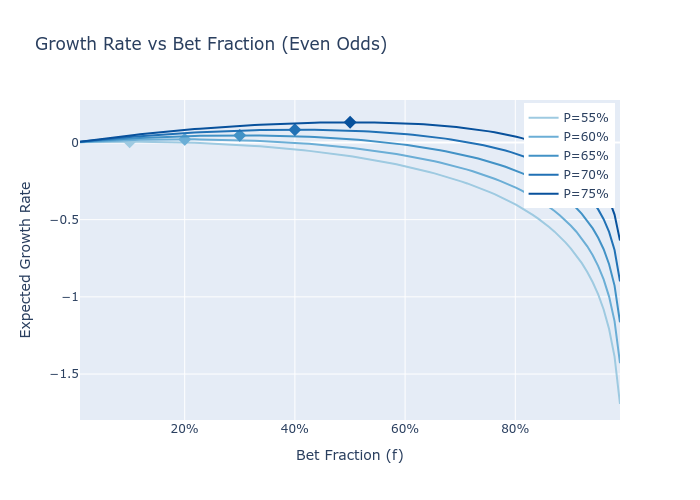

In [10]:
# Compute growth rates for different probabilities and bet fractions
fractions = np.linspace(0.01, 0.99, 100)
probabilities = [0.55, 0.60, 0.65, 0.70, 0.75]

fig = go.Figure()

colors = px.colors.sequential.Blues[3:]

for i, prob in enumerate(probabilities):
    kelly = compute_kelly_fraction(prob)
    growth_rates = [compute_growth_rate(prob, f) for f in fractions]

    fig.add_scatter(
        x=fractions,
        y=growth_rates,
        mode="lines",
        name=f"P={prob:.0%}",
        line=dict(color=colors[i % len(colors)], width=2),
    )

    # Mark optimal Kelly fraction
    optimal_growth = compute_growth_rate(prob, kelly)
    fig.add_scatter(
        x=[kelly],
        y=[optimal_growth],
        mode="markers",
        marker=dict(size=10, color=colors[i % len(colors)], symbol="diamond"),
        showlegend=False,
        hovertemplate=f"Kelly={kelly:.1%}<br>Growth={optimal_growth:.4f}",
    )

fig.update_layout(
    title="Growth Rate vs Bet Fraction (Even Odds)",
    xaxis_title="Bet Fraction (f)",
    yaxis_title="Expected Growth Rate",
    xaxis_tickformat=".0%",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
fig.show()

### Simulating Wealth Paths

In [11]:
def simulate_wealth_paths(
    n_trials: int,
    n_simulations: int,
    win_prob: float,
    fraction: float,
    odds: float = 1.0,
    initial_wealth: float = 100.0,
) -> np.ndarray:
    """Simulate wealth paths for Kelly betting."""
    # Generate random outcomes: 1 = win, 0 = loss
    outcomes = np.random.random((n_trials, n_simulations)) < win_prob

    # Compute growth factors
    growth_factors = np.where(
        outcomes,
        1 + odds * fraction,  # Win
        1 - fraction,  # Loss
    )

    # Cumulative wealth
    wealth = initial_wealth * np.cumprod(growth_factors, axis=0)
    return wealth

#### Percentile-Band Plot Helper

In [12]:
def add_percentile_bands(
    fig: go.Figure, trials: np.ndarray, wealth_pcts: np.ndarray, col_idx: int, showlegend: bool
) -> None:
    """Add 5-95 and 25-75 percentile bands with median path."""
    bands = [
        (4, None),
        (0, "rgba(70, 130, 180, 0.2)"),
        (3, None),
        (1, "rgba(70, 130, 180, 0.4)"),
    ]
    for idx, fillcolor in bands:
        fig.add_scatter(
            x=trials,
            y=wealth_pcts[idx],
            mode="lines",
            line=dict(width=0),
            fill="tonexty" if fillcolor else None,
            fillcolor=fillcolor,
            showlegend=False,
            row=1,
            col=col_idx,
        )
    fig.add_scatter(
        x=trials,
        y=wealth_pcts[2],
        mode="lines",
        line=dict(color="steelblue", width=2),
        name="Median",
        showlegend=showlegend,
        row=1,
        col=col_idx,
    )

In [13]:
# Simulate paths for different Kelly multiples
n_trials = 1000
n_simulations = 500
win_prob = 0.55
odds = 1.0
kelly = compute_kelly_fraction(win_prob, odds)
kelly_multiples = [0.25, 0.5, 1.0, 1.5, 2.0]

fig = make_subplots(
    rows=1,
    cols=len(kelly_multiples),
    subplot_titles=[f"{mult:.0%} Kelly" for mult in kelly_multiples],
    shared_yaxes=True,
)

for i, mult in enumerate(kelly_multiples):
    fraction = kelly * mult
    wealth = simulate_wealth_paths(n_trials, n_simulations, win_prob, fraction, odds)
    wealth_pcts = np.percentile(wealth, [5, 25, 50, 75, 95], axis=1)
    add_percentile_bands(fig, np.arange(n_trials), wealth_pcts, col_idx=i + 1, showlegend=(i == 0))

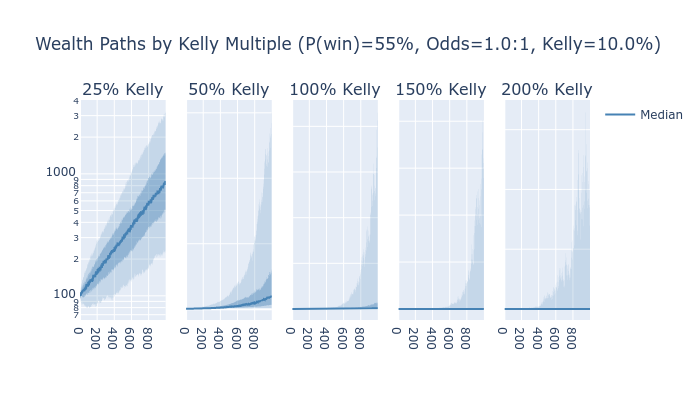


Optimal Kelly fraction: 10.0%
At 2x Kelly (20.0%), left-tail wealth dispersion and drawdown risk increase sharply


In [14]:
fig.update_yaxes(type="log", row=1, col=1)
fig.update_layout(
    title=f"Wealth Paths by Kelly Multiple (P(win)={win_prob:.0%}, Odds={odds}:1, Kelly={kelly:.1%})",
    height=400,
    showlegend=True,
)
fig.show()

print(f"\nOptimal Kelly fraction: {kelly:.1%}")
print(
    f"At 2x Kelly ({2 * kelly:.1%}), left-tail wealth dispersion and drawdown risk increase sharply"
)

### Distribution of Terminal Wealth

In [15]:
def terminal_wealth_distribution(
    n_trials: int,
    win_prob: float,
    fraction: float,
    odds: float = 1.0,
    initial_wealth: float = 100.0,
) -> pl.DataFrame:
    """Compute theoretical distribution of terminal wealth."""
    rv = binom(n=n_trials, p=win_prob)

    results = []
    for n_wins in range(n_trials + 1):
        n_losses = n_trials - n_wins
        log_wealth = (
            np.log(initial_wealth)
            + n_wins * np.log(1 + odds * fraction)
            + n_losses * np.log(1 - fraction)
        )
        prob = rv.pmf(n_wins)
        results.append(
            {
                "n_wins": n_wins,
                "log_wealth": log_wealth,
                "wealth": np.exp(log_wealth),
                "probability": prob,
            }
        )

    return pl.DataFrame(results)

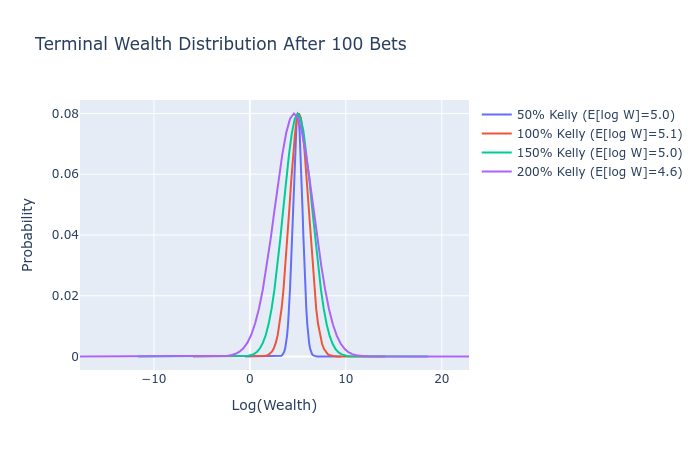

In [16]:
# Compare terminal wealth distributions
n_trials = 100
win_prob = 0.55
kelly = compute_kelly_fraction(win_prob)

fig = go.Figure()

for mult in [0.5, 1.0, 1.5, 2.0]:
    dist = terminal_wealth_distribution(n_trials, win_prob, kelly * mult)

    # Compute expected log wealth
    expected_log_wealth = (dist["log_wealth"] * dist["probability"]).sum()

    fig.add_scatter(
        x=dist["log_wealth"].to_list(),
        y=dist["probability"].to_list(),
        mode="lines",
        name=f"{mult:.0%} Kelly (E[log W]={expected_log_wealth:.1f})",
        line=dict(width=2),
    )

fig.update_layout(
    title=f"Terminal Wealth Distribution After {n_trials} Bets",
    xaxis_title="Log(Wealth)",
    yaxis_title="Probability",
    height=450,
)
fig.show()

## Part 2: Kelly for Continuous Returns (Single Asset)

For continuous return distributions, we use a Taylor expansion of $\log(1+x)$:

$$\log(1+x) \approx x - \frac{x^2}{2} + \frac{x^3}{3} - ...$$

For small returns, the optimal Kelly fraction becomes:

$$f^* \approx \frac{\mu - r_f}{\sigma^2}$$

where $\mu$ is expected return, $r_f$ is risk-free rate, and $\sigma^2$ is variance.

### Taylor Expansion Visualization

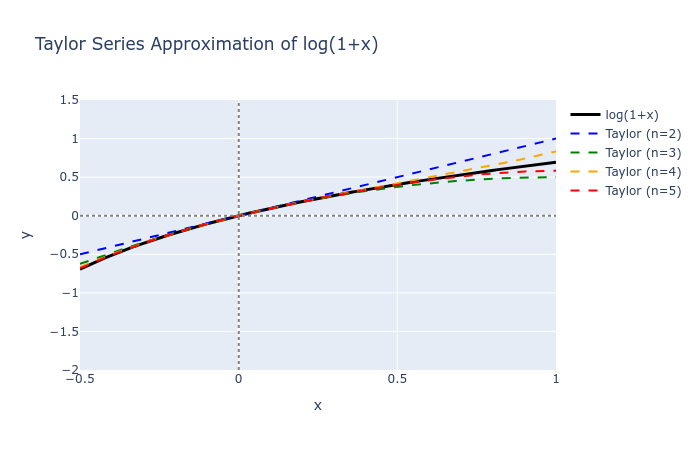

In [17]:
def taylor_polynomial(n_terms: int) -> Callable:
    """Return Taylor polynomial approximation of log(1+x)."""
    x = symbols("x")
    expansion = series(log(1 + x), x, x0=0, n=n_terms).removeO()
    return sympy.lambdify(x, expansion, "numpy")


# Compare Taylor approximations
x_vals = np.linspace(-0.5, 1.0, 200)
true_log = np.log(1 + x_vals)

fig = go.Figure()

fig.add_scatter(
    x=x_vals, y=true_log, mode="lines", name="log(1+x)", line=dict(width=3, color="black")
)

colors = ["blue", "green", "orange", "red"]
for i, n in enumerate([2, 3, 4, 5]):
    taylor = taylor_polynomial(n)
    approx = taylor(x_vals)
    fig.add_scatter(
        x=x_vals,
        y=approx,
        mode="lines",
        name=f"Taylor (n={n})",
        line=dict(width=2, dash="dash", color=colors[i]),
    )

fig.update_layout(
    title="Taylor Series Approximation of log(1+x)",
    xaxis_title="x",
    yaxis_title="y",
    yaxis_range=[-2, 1.5],
    height=450,
)
fig.add_vline(x=0, line_dash="dot", line_color="gray")
fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.show()

### Kelly Fraction for Market Returns

In [18]:
def kelly_fraction_continuous(
    mean_return: float, std_return: float, risk_free: float = 0.0
) -> float:
    """Kelly fraction for normally distributed returns."""
    excess_return = mean_return - risk_free
    return excess_return / (std_return**2)

#### Numerical Growth Objective

In [19]:
def growth_rate_continuous(
    mean: float, std: float, fraction: float, risk_free: float = 0.0
) -> float:
    """Expected growth rate of a fractional risky/risk-free allocation.

    The wealth multiple on a step where the risky return realizes as r is
    ``1 + r_f + f·(r − r_f)``. The ruin boundary lies at r* = r_f − (1 + r_f)/f.
    Below it the integrand uses ``log(1e-12)`` as a finite penalty so the
    optimizer avoids ruin without injecting NaN into the quadrature; this is
    a numerical approximation, not a true ruin contribution of zero mass.
    """

    def integrand(r):
        arg = 1.0 + risk_free + fraction * (r - risk_free)
        return np.log(np.maximum(arg, 1e-12)) * norm.pdf(r, mean, std)

    lower = mean - 4 * std
    upper = mean + 4 * std
    if fraction > 0:
        boundary = risk_free - (1.0 + risk_free) / fraction
        if lower < boundary < upper:
            # Split the integral at the boundary so quad doesn't see a discontinuity.
            v1, _ = quad(integrand, lower, boundary - 1e-9, limit=200)
            v2, _ = quad(integrand, boundary + 1e-9, upper, limit=200)
            return v1 + v2
    val, _ = quad(integrand, lower, upper, limit=200)
    return val

#### Numerical Optimizer for Kelly Fraction

In [20]:
def optimal_kelly_numerical(mean: float, std: float, risk_free: float = 0.0) -> float:
    """Find optimal Kelly fraction numerically against a risk-free alternative."""
    result = minimize_scalar(
        lambda f: -growth_rate_continuous(mean, std, f, risk_free),
        bounds=[0.01, 5.0],
        method="bounded",
    )
    return result.x

In [21]:
# Load SPY as proxy for S&P 500 from canonical data
etf_data = load_etfs()
spy_data = etf_data.filter(pl.col("symbol") == "SPY").sort("timestamp")
sp500_prices = spy_data.select(["timestamp", "close"]).to_pandas().set_index("timestamp")["close"]
sp500_returns = sp500_prices.pct_change().dropna()

# Compute annual statistics
annual_ret = sp500_returns.mean() * 252
annual_vol = sp500_returns.std() * np.sqrt(252)
risk_free = 0.02  # Assume 2% risk-free rate

print("S&P 500 Statistics (2000-2024):")
print(f"  Annual Return: {annual_ret:.2%}")
print(f"  Annual Volatility: {annual_vol:.2%}")
print(f"  Sharpe Ratio: {(annual_ret - risk_free) / annual_vol:.2f}")

# Kelly fractions — both estimators take the same annual risk-free rate
# so the analytical Taylor approximation and the numerical optimizer are
# compared like-for-like.
kelly_approx = kelly_fraction_continuous(annual_ret, annual_vol, risk_free)
kelly_numerical = optimal_kelly_numerical(annual_ret, annual_vol, risk_free)

print("\nKelly Fractions:")
print(f"  Analytical (Taylor approx): {kelly_approx:.1%}")
print(f"  Numerical optimization:     {kelly_numerical:.1%}")

S&P 500 Statistics (2000-2024):
  Annual Return: 12.17%
  Annual Volatility: 19.39%
  Sharpe Ratio: 0.52

Kelly Fractions:
  Analytical (Taylor approx): 270.6%
  Numerical optimization:     172.7%


### Rolling Kelly Fraction

In [22]:
# Compute rolling Kelly fraction
rolling_window = min(252 * 5, max(63, len(sp500_returns) // 2))
rolling_window_years = rolling_window / 252

# Convert to Polars for efficient computation
returns_pl = pl.DataFrame(
    {
        "timestamp": sp500_returns.index.to_list(),
        "return": sp500_returns.values,
    }
)

# Rolling mean and std
rolling_stats = returns_pl.with_columns(
    [
        pl.col("return").rolling_mean(window_size=rolling_window).alias("rolling_mean"),
        pl.col("return").rolling_std(window_size=rolling_window).alias("rolling_std"),
    ]
).drop_nulls()

# Compute Kelly fraction
rolling_stats = rolling_stats.with_columns(
    [
        ((pl.col("rolling_mean") * 252 - risk_free) / (pl.col("rolling_std") ** 2 * 252)).alias(
            "kelly"
        ),
    ]
)

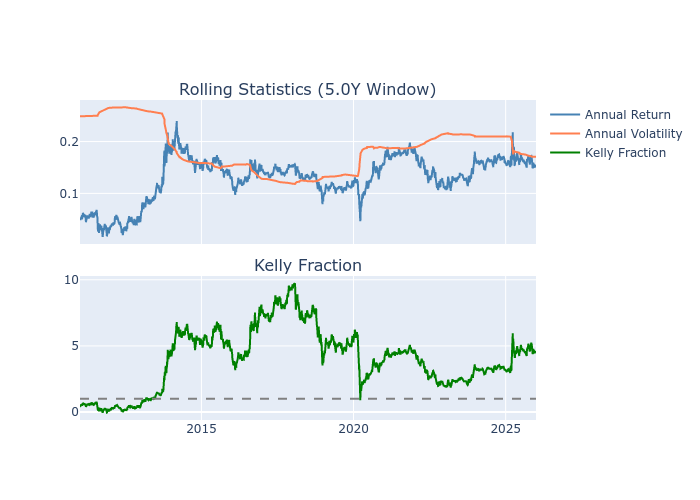

In [23]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=[f"Rolling Statistics ({rolling_window_years:.1f}Y Window)", "Kelly Fraction"],
)

# Rolling return and volatility
fig.add_scatter(
    x=rolling_stats["timestamp"].to_list(),
    y=(rolling_stats["rolling_mean"] * 252).to_list(),
    name="Annual Return",
    line=dict(color="steelblue"),
    row=1,
    col=1,
)
fig.add_scatter(
    x=rolling_stats["timestamp"].to_list(),
    y=(rolling_stats["rolling_std"] * np.sqrt(252)).to_list(),
    name="Annual Volatility",
    line=dict(color="coral"),
    row=1,
    col=1,
)

# Kelly fraction
kelly_values = rolling_stats["kelly"].to_list()
fig.add_scatter(
    x=rolling_stats["timestamp"].to_list(),
    y=kelly_values,
    name="Kelly Fraction",
    line=dict(color="green"),
    row=2,
    col=1,
)
fig.add_hline(y=1.0, line_dash="dash", line_color="gray", row=2, col=1)

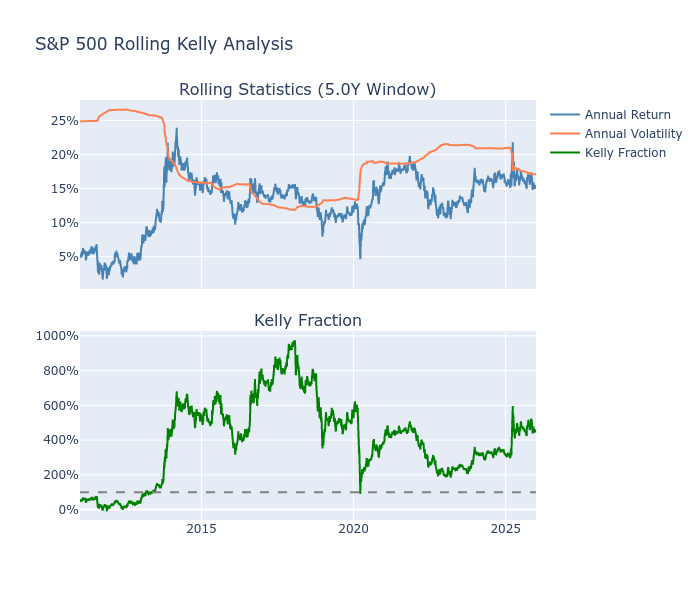


Kelly Fraction Statistics:
  Mean: 401.7%
  Std:  230.7%
  Min:  -5.5%
  Max:  974.1%


In [24]:
fig.update_yaxes(tickformat=".0%", row=1, col=1)
fig.update_yaxes(tickformat=".0%", row=2, col=1)
fig.update_layout(height=600, title="S&P 500 Rolling Kelly Analysis")
fig.show()

print("\nKelly Fraction Statistics:")
print(f"  Mean: {np.mean(kelly_values):.1%}")
print(f"  Std:  {np.std(kelly_values):.1%}")
print(f"  Min:  {np.min(kelly_values):.1%}")
print(f"  Max:  {np.max(kelly_values):.1%}")

## Part 3: Kelly for Multiple Assets

For a portfolio of $n$ assets, the optimal Kelly allocation is:

$$\mathbf{f}^* = \Sigma^{-1} \boldsymbol{\mu}$$

where $\Sigma^{-1}$ is the **precision matrix** (inverse covariance) and $\boldsymbol{\mu}$
is the vector of expected returns.

This result is equivalent to the **maximum Sharpe ratio portfolio** from mean-variance optimization!

### Load Multi-Asset Data

In [25]:
# Load data for a set of ETFs from canonical data
tickers = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ"]
start_date = "2010-01-01"
end_date = "2024-12-01"

# Load from canonical ETF data
multi_etf = etf_data.filter(
    (pl.col("symbol").is_in(tickers))
    & (pl.col("timestamp") >= pl.lit(start_date).str.to_datetime())
    & (pl.col("timestamp") <= pl.lit(end_date).str.to_datetime())
)
prices = (
    multi_etf.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
    .ffill()
    .dropna()
)
returns = prices.pct_change().dropna()

print(f"Data: {len(returns)} trading days, {len(tickers)} assets")
returns.describe().round(4)

Data: 3752 trading days, 8 assets


,EEM,EFA,GLD,IWM,QQQ,SPY,TLT,VNQ
count,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000
mean,0.0002,0.0003,0.0003,0.0005,0.0008,0.0006,0.0002,0.0005
std,0.0136,0.0117,0.0098,0.0140,0.0129,0.0108,0.0096,0.0131
min,-0.1248,-0.1099,-0.0878,-0.1327,-0.1198,-0.1094,-0.0667,-0.1773
25%,-0.0071,-0.0051,-0.0048,-0.0067,-0.0047,-0.0037,-0.0057,-0.0056
50%,0.0007,0.0006,0.0004,0.0010,0.0012,0.0007,0.0006,0.0008
75%,0.0077,0.0063,0.0055,0.0081,0.0073,0.0058,0.0059,0.0071
max,0.0805,0.0847,0.0490,0.0915,0.0847,0.0906,0.0752,0.0910


In [26]:
assets = returns.columns.tolist()
print(f"Assets with complete history: {len(assets)}")

Assets with complete history: 8


In [27]:
# Compute statistics
annual_returns = returns.mean() * 252
annual_cov = returns.cov() * 252

print("Annualized Returns:")
print(annual_returns.round(4))
print(f"\nCovariance Matrix Condition Number: {np.linalg.cond(annual_cov):.1f}")

Annualized Returns:
EEM    0.0444
EFA    0.0684
GLD    0.0661
IWM    0.1279
QQQ    0.1909
SPY    0.1452
TLT    0.0421
VNQ    0.1136
dtype: float64

Covariance Matrix Condition Number: 181.4


### Kelly Portfolio Allocation

In [28]:
# Compute precision matrix
precision_matrix = pd.DataFrame(
    inv(annual_cov),
    index=assets,
    columns=assets,
)

# Kelly allocation
kelly_allocation = precision_matrix.dot(annual_returns)

print("Raw Kelly Allocation (can exceed 100%):")
print(kelly_allocation.round(3))
print(f"\nTotal leverage: {kelly_allocation.abs().sum():.1%}")

Raw Kelly Allocation (can exceed 100%):
EEM    -4.560
EFA    -4.033
GLD     3.107
IWM    -1.872
QQQ     2.386
SPY    14.316
TLT     2.858
VNQ    -0.886
dtype: float64

Total leverage: 3401.8%


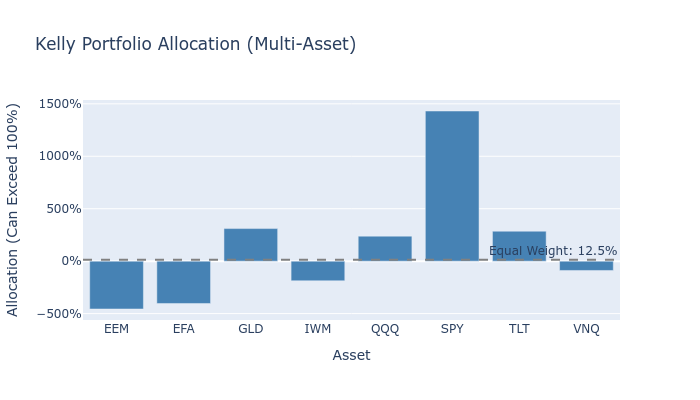


Kelly allocation suggests 1132% total exposure


In [29]:
fig = go.Figure()

fig.add_bar(
    x=assets,
    y=kelly_allocation.values,
    name="Kelly (Raw)",
    marker_color="steelblue",
)

# Add reference line for equal weight
fig.add_hline(
    y=1 / len(assets),
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Equal Weight: {1 / len(assets):.1%}",
)

fig.update_layout(
    title="Kelly Portfolio Allocation (Multi-Asset)",
    xaxis_title="Asset",
    yaxis_title="Allocation (Can Exceed 100%)",
    yaxis_tickformat=".0%",
    height=400,
)
fig.show()

print(f"\nKelly allocation suggests {kelly_allocation.sum():.0%} total exposure")

### Fractional Kelly for Risk Management

Full Kelly is often too aggressive in practice due to:
- Estimation error in $\mu$ and $\Sigma$
- Non-normal return distributions (fat tails)
- Borrowing constraints

**Half-Kelly** ($f^*/2$) is common in practice, sacrificing some growth for stability.

In [30]:
# Compare different Kelly fractions. Raw fractional weights are used directly
# — no gross-normalization — so different Kelly multiples produce genuinely
# different leverage levels. The reported gross exposure reveals how
# aggressive each multiple is relative to equal weight.
kelly_multiples = [0.25, 0.5, 1.0]
returns_np = returns.values

portfolio_returns = {}
portfolio_gross = {}
for mult in kelly_multiples:
    weights = kelly_allocation.values * mult
    gross = float(np.abs(weights).sum())

    pf_returns = returns_np @ weights
    portfolio_returns[f"{mult:.0%} Kelly"] = pf_returns
    portfolio_gross[f"{mult:.0%} Kelly"] = gross

# Add equal weight for comparison (gross = 1.0 by construction)
equal_weights = np.full(len(assets), 1 / len(assets))
portfolio_returns["Equal Weight"] = returns_np @ equal_weights
portfolio_gross["Equal Weight"] = float(np.abs(equal_weights).sum())

print("Gross exposure by Kelly multiple (no cap applied):")
print(pd.Series(portfolio_gross, name="gross_exposure").round(2).map("{:.2f}".format))

Gross exposure by Kelly multiple (no cap applied):
25% Kelly        8.50
50% Kelly       17.01
100% Kelly      34.02
Equal Weight     1.00
Name: gross_exposure, dtype: object


### Performance Comparison with ml4t-diagnostic

In [31]:
# Convert to Polars and analyze
dates = returns.index.to_list()
comparison_metrics = []

for name, pf_ret in portfolio_returns.items():
    pa = PortfolioAnalysis(
        returns=pl.Series("returns", pf_ret),
        dates=pl.Series("timestamp", dates),
        risk_free=risk_free,
        periods_per_year=252,
    )

    metrics = pa.compute_summary_stats()
    comparison_metrics.append(
        {
            "Strategy": name,
            "Annual Return": metrics.annual_return,
            "Annual Vol": metrics.annual_volatility,
            "Sharpe": metrics.sharpe_ratio,
            "Sortino": metrics.sortino_ratio,
            "Max DD": metrics.max_drawdown,
            "Calmar": metrics.calmar_ratio,
            "Gross Exposure": portfolio_gross[name],
        }
    )

metrics_df = pl.DataFrame(comparison_metrics)
metrics_df

Strategy,Annual Return,Annual Vol,Sharpe,Sortino,Max DD,Calmar,Gross Exposure
str,f64,f64,f64,f64,f64,f64,f64
"""25% Kelly""",0.562256,0.357183,1.373287,1.342627,-0.562829,0.998981,8.504482
"""50% Kelly""",1.145432,0.714365,1.401009,1.370123,-0.872034,1.313517,17.008963
"""100% Kelly""",1.704845,1.428731,1.41487,1.384507,-0.997071,1.709853,34.017927
"""Equal Weight""",0.094867,0.135291,0.591506,0.55927,-0.269102,0.352532,1.0


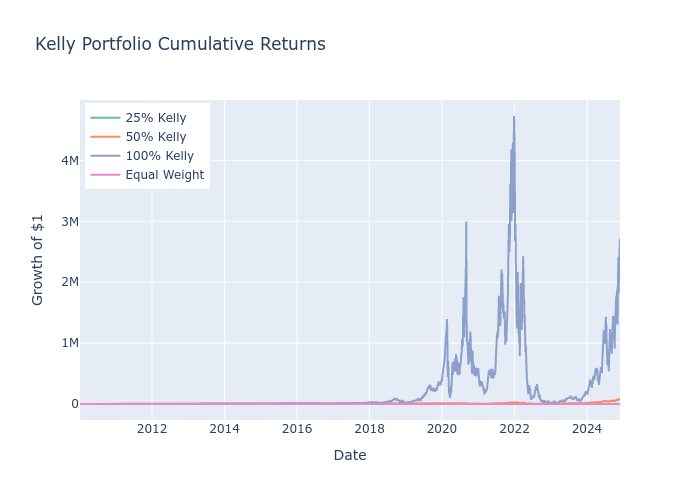

In [32]:
# Cumulative returns comparison
fig = go.Figure()

colors = px.colors.qualitative.Set2

for i, (name, pf_ret) in enumerate(portfolio_returns.items()):
    cum_ret = (1 + pf_ret).cumprod()
    fig.add_scatter(
        x=dates,
        y=cum_ret,
        mode="lines",
        name=name,
        line=dict(color=colors[i % len(colors)], width=2),
    )

fig.update_layout(
    title="Kelly Portfolio Cumulative Returns",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

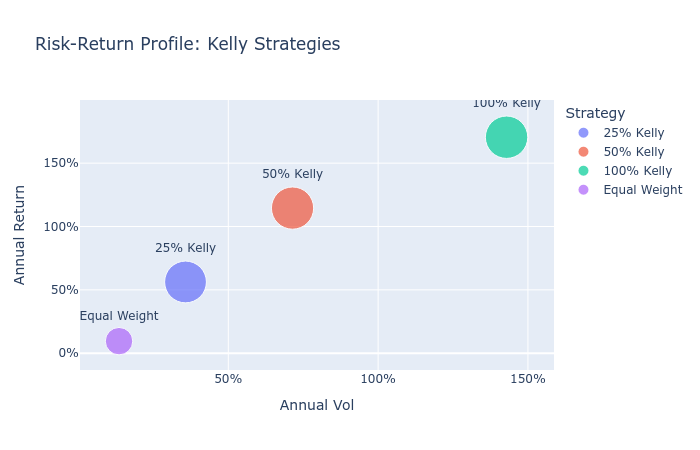

In [33]:
# Risk-return scatter
metrics_pd = metrics_df.to_pandas()
# Use abs Sharpe for size (plotly requires non-negative values)
metrics_pd["Sharpe_size"] = metrics_pd["Sharpe"].abs().clip(lower=0.1)

fig = px.scatter(
    metrics_pd,
    x="Annual Vol",
    y="Annual Return",
    size="Sharpe_size",
    color="Strategy",
    text="Strategy",
    size_max=30,
    title="Risk-Return Profile: Kelly Strategies",
)

fig.update_traces(textposition="top center")
fig.update_layout(
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=450,
)
fig.show()

## Part 4: Practical Considerations

### When Kelly Works Well
- **Known edge**: The probability distribution is well-estimated
- **Many bets**: Long time horizon allows law of large numbers to work
- **Reinvestment**: Profits are continuously reinvested

### Challenges in Finance
- **Estimation error**: Returns are not stationary, $\mu$ and $\sigma$ change
- **Fat tails**: Real returns have more extreme events than normal
- **Correlation changes**: Covariance matrix shifts in crises
- **Leverage costs**: Borrowing is not free

### Best Practices
1. **Use fractional Kelly** (half or quarter) to account for uncertainty
2. **Combine with risk constraints** (max position size, VaR limits)
3. **Regularize covariance estimates** (Ledoit-Wolf shrinkage)
4. **Monitor and adjust** as market conditions change

In [34]:
# Example: Shrinkage estimator for more stable Kelly allocation
lw = LedoitWolf()
lw.fit(returns.values)
shrunk_cov = pd.DataFrame(lw.covariance_ * 252, index=assets, columns=assets)
shrunk_precision = pd.DataFrame(inv(shrunk_cov), index=assets, columns=assets)

kelly_shrunk = shrunk_precision.dot(annual_returns)

print("Kelly Allocation Comparison:")
print("-" * 50)
comparison = pd.DataFrame(
    {
        "Raw Covariance": kelly_allocation,
        "Shrunk Covariance": kelly_shrunk,
        "Difference": kelly_allocation - kelly_shrunk,
    }
)
print(comparison.round(3))
print(f"\nTotal leverage (raw):    {kelly_allocation.abs().sum():.1%}")
print(f"Total leverage (shrunk): {kelly_shrunk.abs().sum():.1%}")

Kelly Allocation Comparison:
--------------------------------------------------
     Raw Covariance  Shrunk Covariance  Difference
EEM          -4.560             -4.569       0.009
EFA          -4.033             -3.651      -0.383
GLD           3.107              3.056       0.050
IWM          -1.872             -1.629      -0.242
QQQ           2.386              3.107      -0.721
SPY          14.316             12.598       1.719
TLT           2.858              2.756       0.103
VNQ          -0.886             -0.670      -0.216

Total leverage (raw):    3401.8%
Total leverage (shrunk): 3203.5%


In [35]:
# Save results
results = pl.DataFrame(
    {
        "ticker": assets,
        "kelly_raw": kelly_allocation.values,
        "kelly_shrunk": kelly_shrunk.values,
    }
)
OUTPUT_DIR = get_output_dir(17, "kelly")
results.write_parquet(OUTPUT_DIR / "kelly_allocations.parquet")
print(f"Saved Kelly allocations to {OUTPUT_DIR / 'kelly_allocations.parquet'}")

Saved Kelly allocations to 17_portfolio_construction/output/kelly/kelly_allocations.parquet


## Key Takeaways

1. **Kelly = max geometric growth**, but raw Kelly leverage (~3,200--3,400%) is
   impractical. The signal-to-noise ratio of return estimates is far too low
   to justify full Kelly sizing.

2. **Fractional Kelly (25--50%) with shrinkage covariance** is the production
   pattern. It preserves the growth-optimal direction while drastically reducing
   estimation sensitivity.

3. **Kelly and MVO are equivalent** when the risk-free rate is zero: the
   max-Sharpe portfolio *is* the Kelly portfolio. Both suffer from the same
   precision-matrix instability when covariance estimates are noisy.

4. **Treat Kelly output as an upper bound**, not a target. The gap between
   theoretical and practical Kelly is a measure of estimation risk.

**Next**: [`06_hierarchical_risk_parity`](06_hierarchical_risk_parity.ipynb) introduces a cluster-based allocation
that avoids precision-matrix inversion entirely.

**Book**: §17.4 covers Kelly sizing among the baseline allocators.